<a href="https://colab.research.google.com/github/jppeirce/DSC210-Foundations-of-Data-Science/blob/main/Homework/HW03-arrays_and_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 3: Arrays and Data Visualization

**DSC 210 Foundations of Data Science**

*Covers Module 2, Section 3 (feature types), Module 4, Section 2 (2D arrays, `axis`, correlation, z-scores), and Module 5 (data visualization with seaborn).*

References:
- Module 4 and Module 5 course notebooks
- [Hands-on Introduction to Data Science with Python](https://florian-huber.github.io/data_science_course/) (CC BY-NC-SA 4.0)
- `titanic` dataset, included with the `seaborn` package
- Gapminder 2007 data: free data from [gapminder.org](https://www.gapminder.org/data/), CC BY 4.0 (as in Module 5)
- Bike sharing data: Fanaee-T, H. and Gama, J. (2013). Event labeling combining ensemble detectors and background knowledge. *Progress in Artificial Intelligence*, 1-15. [doi:10.1007/s13748-013-0040-3](https://doi.org/10.1007/s13748-013-0040-3). Data via the [UCI Machine Learning Repository, Bike Sharing dataset](https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset); original trip data from Capital Bikeshare, Washington, D.C.

*Last major revision: 2026-09-27 (DRAFT)*

## Key Concepts

- Read a 2D array and summarize it along the correct `axis`
- Review code critically: a cell that runs without an error can still give a wrong answer
- Compute and interpret a correlation
- Classify each variable in a dataset by **family and scale**, and use those types to choose a plot
- Take a **first look** at a new dataset by graphing every variable, a preview of EDA
- Choose, build, and fully label an appropriate plot for a question
- Use a log scale when a linear one hides the data
- Write a **Professional Summary**: report a finding in the register a colleague would expect

---

## Instructions

**Total: 50 points.** Point values are listed with each problem.

- Cells marked `# FILL-IN` contain blanks written as `____` and will raise a `SyntaxError` until every blank is replaced.
- Where you are asked to produce a plot, **every figure must include a title and labeled axes.**
- Most of the credit in this assignment rides on your written interpretation, not on styling. Say what the picture shows.
- Submit the completed `.ipynb`, with all cells run and all figures visible, to Canvas.

---
## Part 0. Setup check (2 points)
---

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

penguins = sns.load_dataset('penguins')
planets  = sns.load_dataset('planets')
bikes    = pd.read_csv('https://raw.githubusercontent.com/jppeirce/DSC210-Foundations-of-Data-Science/main/csv_data/bike_sharing/day.csv')

print('penguins shape:', penguins.shape)
print('planets shape :', planets.shape)
print('bikes shape   :', bikes.shape)
print('planets columns:', list(planets.columns))

penguins shape: (344, 7)
planets shape : (1035, 6)
bikes shape   : (731, 16)
planets columns: ['method', 'number', 'orbital_period', 'mass', 'distance', 'year']


**Problem 0.** (2 points) Report the three shapes and the `planets` column names printed above. If anything errored, paste the message.

**Your answer:**

---
## Part A. Short answer (14 points)
---

### Problem A1. Reading a 2D array (6 points)

Here are daily high temperatures (degrees F) for one week in three cities. Each **row** is a day (Monday through Friday) and each **column** is a city (0 = La Crosse, 1 = Minneapolis, 2 = Chicago).

```python
T = np.array([[58, 55, 61],    # Mon
              [64, 60, 66],    # Tue
              [71, 68, 70],    # Wed
              [66, 63, 69],    # Thu
              [61, 59, 64]])   # Fri
```

Work (a) and (b) **by hand** first. You may check your answers in the code cell below afterward.

(a) Write one NumPy expression for each:

- (i) Minneapolis's high on every day
- (ii) all three cities' highs on Wednesday
- (iii) the average high in each city over the week (three numbers)
- (iv) Chicago's highs for Tuesday through Thursday

(b) Predict the exact output of each expression:

- (i) `T.shape`
- (ii) `T.max(axis=1)`, and say in words what these numbers are
- (iii) `T[T[:, 0] > 62, 1]`, and say in words what these numbers are

(c) **Spot and fix.** A classmate wants each city's average high and writes `T.mean(axis=1)`. The code runs without an error. How many numbers does it return, what do they actually mean, and what is the fix? Why is "it ran without an error" not evidence that the code is right?

**Your answer:**

(a) (i) T[:,1]
(ii) T[2,:]
(iii) T.mean(axis=0)
(iv) T[1:4,2]

(b) (i) 5,3
(ii) 61,66,71,69,64 ; The high from the city with the largest high on a given day.
(iii) 60,68,63 ; The high in Mineapolis for each day in which the high in lacrosse is greater than 62.

(c) This code would return 5 numbers that tell the average high across all cities for each day. The fix is to use axis=0 to compute mean by column. Code can be built in ways other than intended and still run without throwing errors.

In [9]:
# Optional: check your hand answers to A1 here.
T = np.array([[58, 55, 61],
              [64, 60, 66],
              [71, 68, 70],
              [66, 63, 69],
              [61, 59, 64]])

array([60, 68, 63])

### Problem A2. From variable types to plot choice (8 points)

**Scenario.** You have just been hired as an analyst for Capital Bikeshare, the bike share system in Washington, D.C. Your manager hands you two years of daily records (2011 and 2012: 731 days, 16 columns, already loaded as `bikes`) and asks one question: *what drives ridership?*

Before you draw anything, you need to know what kind of variable each column is. Here is the data dictionary, adapted from the dataset's Readme.

| Column | Stored as | Description |
| --- | --- | --- |
| `instant` | integer | record number, 1 to 731 |
| `dteday` | text | the date, e.g. `2011-01-01` |
| `season` | integer | 1 to 4 (the Readme labels these 1 = spring, 2 = summer, 3 = fall, 4 = winter; see the stretch in Problem C1) |
| `yr` | integer | 0 = 2011, 1 = 2012 |
| `mnth` | integer | month, 1 to 12 |
| `holiday` | integer | 1 if the day is a public holiday, else 0 |
| `weekday` | integer | day of the week, 0 = Sunday through 6 = Saturday |
| `workingday` | integer | 1 if the day is neither a weekend nor a holiday, else 0 |
| `weathersit` | integer | 1 = clear or partly cloudy, 2 = mist or cloudy, 3 = light rain or light snow, 4 = heavy rain, ice, or snow |
| `temp` | decimal | temperature in degrees Celsius, divided by 41 |
| `atemp` | decimal | "feels like" temperature in degrees Celsius, divided by 50 |
| `hum` | decimal | relative humidity (percent), divided by 100 |
| `windspeed` | decimal | wind speed, divided by 67 |
| `casual` | integer | number of rides that day by casual (non-member) riders |
| `registered` | integer | number of rides that day by registered members |
| `cnt` | integer | total rides that day |

Fifteen of the sixteen columns are stored as numbers. Recall the warning from Module 2: how Python *stores* a feature does not tell you what it *means*.

**(a) (3 points)** Complete the table below for the remaining columns. For **Family**, write *categorical*, *numerical*, or *other* (an identifier or a date). For **Scale**, write nominal, ordinal, interval, or ratio (leave it blank for *other*). Two rows are done for you. A few columns could reasonably go more than one way; if so, pick one and defend it in your reason. You are graded on the reasoning, not only the label.

**Your answer:**

| Column | Family | Scale | One-phrase reason |
| --- | --- | --- | --- |
| `instant` | other | x| a row number: it labels each day but measures nothing |
| `dteday` | other | x| a date |
| `season` | categorical | ordinal| equal interval season categories|
| `yr` |categorical| ordinal| year between 2011 or 2012|
| `mnth` | categorical | ordinal | equal interval month categories|
| `holiday` | categorical | nominal | two boolean categories that have no measurable interval saying if there is a holiday|
| `weekday` |categorical| ordinal| equal interval weekday catgories |
| `workingday` |categorical |nominal | two boolean caegories that have no measurable interval saying if there is work |
| `weathersit` |categorcial | nominal| weather categories with no even interval|
| `temp` |  numerical| interval | temp value with no true zero|
| `atemp` | other|x | A value that is determined by a lot of different feels-like factors. |
| `hum` | numerical| ratio | a value betwee 0 and 100 for percent humidity |
| `windspeed` | numerical | ratio | a value from 0 depicting wind speed|
| `casual` | numerical|ratio | count if casual riders
| `registered` | numerical| ratio|count of registered riders |
| `cnt` | numerical | ratio | a count of rides: 0 means no rides, and 8000 rides is twice 4000 |

**(b) (5 points)** For each question below, name the variables involved, their families (for example, *numerical + categorical*), the plot you would draw, and the `hue` variable if any. Then, in row 5, propose **one question of your own** that uses a different combination of columns, and fill in its row the same way.

| # | Question |
| --- | --- |
| 1 | Do fewer people ride on bad-weather days? |
| 2 | Does ridership rise with temperature, and does the pattern look different across seasons? |
| 3 | Do casual riders and registered members respond differently to working days versus days off? |
| 4 | Did daily ridership grow from 2011 to 2012? |
| 5 | *Your question:* |

**Your answer:**

| # | Variables | Families | Plot | hue? |
| --- | --- | --- | --- | --- |
| 1 | cnt , weathersit| categorical, numerical | boxplot |  |
| 2 | cnt , temp, seasons| numerical, categorical|  scatterplot| seasons|
| 3 | cnt , workingday, casual, registered | numerical, categorical, other| Bar Chart | |
| 4 | cnt, year| numerical categorical| boxplot | |
| 5 | | | | |

Look down your **Families** column. When we plot, the type of plot is chosen by the *types* of the variables, not by their names. Later in the semester, the same habit will help us choose a model.

---
## Part B. Code completion and review (10 points)
---

### Problem B1. Code review: four quiet bugs (6 points)

A classmate wrote the cell below to answer four questions about the Gapminder 2007 data (Module 5). **Every line runs without an error, and every answer is wrong.** Code that runs is not the same as code that is right, so part of a data scientist's job is asking, "Is this number even possible?"

Run the setup cell and the classmate's cell. Then:

- in the table, say for each numbered line what in the **printed output** should make you suspicious, and what the bug is;
- in the last code cell, write a corrected version of each line and run it.

In [10]:
# RUN-TOGETHER  (setup for Problem B1)
gm = pd.read_csv('https://raw.githubusercontent.com/jppeirce/DSC210-Foundations-of-Data-Science/main/csv_data/gapminder_2007.csv')
life = gm['life_exp'].to_numpy()     # life expectancy, years
gdp  = gm['gdp_cap'].to_numpy()      # GDP per capita, US dollars
print('countries:', life.size)

countries: 142


In [15]:
# RUN-TOGETHER  (a classmate's code: it runs, but every answer is wrong)

# 1. Correlation between GDP per capita and life expectancy
print('1. r =', np.corrcoef(gdp, life)[0, 0])

# 2. z-scores of life expectancy
z_life = (life - life.mean()) / gdp.std()
print('2. smallest and largest z:', round(z_life.min(), 4), round(z_life.max(), 4))

# 3. Fraction of countries with life expectancy over 70 years
print('3. fraction over 70:', (life > 70).sum())

# 4. Average GDP per capita of the countries with life expectancy under 50 years
print('4. average GDP per capita:', round(life[life < 50].mean(), 2))

1. r = 1.0
2. smallest and largest z: -0.0021 0.0012
3. fraction over 70: 83
4. average GDP per capita: 45.23


**Your answer:**

| Line | What in the output is suspicious? | What is the bug? |
| --- | --- | --- |
| 1 | The corelation is perfectly corelated | It takes the corelation between the first variable and itself |
| 2 | Numbers are very close to zero | Compares to the standard deviation of gdp instead of life expectancy resulting in a small number |
| 3 | Outputs a whole number for a fraction | Uses sum rather than mean to compute the proportion of a boolean array |
| 4 | The number is small for a gdp | finds the average life expectency rather than average gdp |

In [16]:
# Problem B1: your corrected lines here
# 1. Correlation between GDP per capita and life expectancy
print('1. r =', np.corrcoef(gdp, life)[0, 1])

# 2. z-scores of life expectancy
z_life = (life - life.mean()) / life.std()
print('2. smallest and largest z:', round(z_life.min(), 4), round(z_life.max(), 4))

# 3. Fraction of countries with life expectancy over 70 years
print('3. fraction over 70:', (life > 70).mean())

# 4. Average GDP per capita of the countries with life expectancy under 50 years
print('4. average GDP per capita:', round(gdp[life < 50].mean(), 2))

1. r = 0.6786623986777587
2. smallest and largest z: -2.2771 1.2963
3. fraction over 70: 0.5845070422535211
4. average GDP per capita: 1740.32


### Problem B2. Labeled figures for a familiar dataset (4 points)

You queried the `titanic` data with masks in Homework 2. Now picture it. Fill in the blanks so each figure has an informative title and labeled axes.

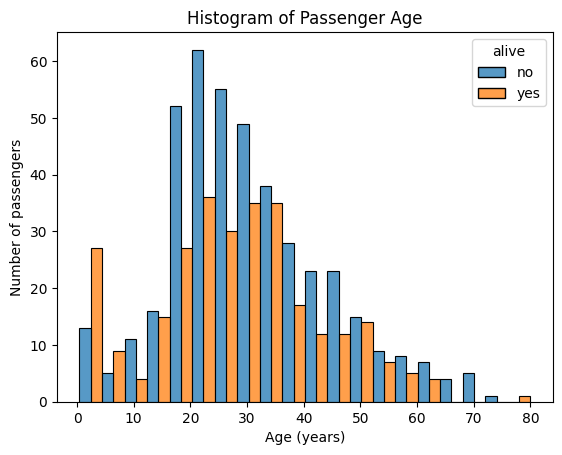

In [17]:
# FILL-IN  (Problem B2)
titanic = sns.load_dataset('titanic')

# (a) Histogram of passenger age, colored by whether the passenger survived (column 'alive').
sns.histplot(data=titanic, x='age', hue='alive', multiple='dodge')
plt.title("Histogram of Passenger Age")
plt.xlabel('Age (years)')
plt.ylabel('Number of passengers')
plt.show()

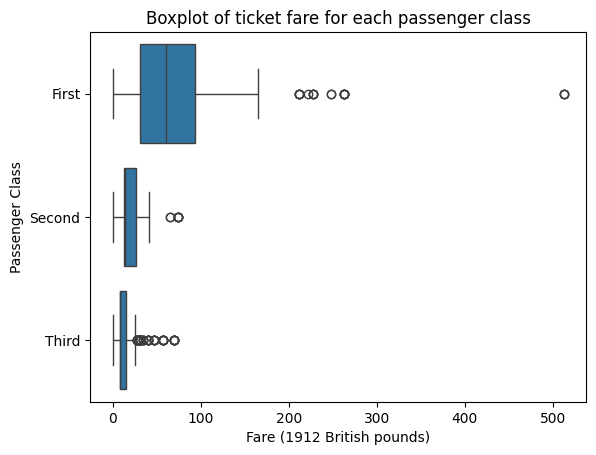

In [22]:
# FILL-IN  (Problem B2 continued)
# (b) Boxplot of ticket fare for each passenger class (column 'class').
sns.boxplot(data=titanic, x='fare', y='class')
plt.title('Boxplot of ticket fare for each passenger class')
plt.ylabel('Passenger Class')
plt.xlabel('Fare (1912 British pounds)')
plt.show()

(c) Interpret your two figures.

- (i) In most age bins the "no" bar is taller. Name the age range where the "yes" bar is clearly taller. Then explain why comparing bar *heights* across the two colors does not directly tell you survival *rates*. (Hint: how many passengers are in each group overall?)
- (ii) Which class has by far the widest spread of fares, and what do the separately plotted points for that class represent? Name one thing about First-class fares that a histogram would show but this boxplot cannot.

**Your answer:**

(i) The 0 to 4 bin has 'yes' as the taller bar. This does not clearly tell the survival rates because there may be more passengers of a certain age range.

(ii)First class had the largest spread of fares. The seperately plotted points represent those who were given a higher than most other passengers. A histogram would better represent the data within each quartile-section for first class.

---
## Part C. Guided coding (12 points)
---

### Problem C1. First look: one graph per variable (6 points)

Before asking questions about relationships, an analyst's first habit with a new dataset is to graph every variable on its own and ask what each picture shows. We will build this habit into a full process in Module 7 (exploratory data analysis); this problem is the first step.

Run the setup cell. It converts `temp` back to degrees Celsius using broadcasting (Module 4), so your axis can carry real units.

In [23]:
# RUN-TOGETHER  (setup for Problem C1)
bikes['temp_C'] = bikes['temp'] * 41
bikes.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,temp_C
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985,14.110847
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801,14.902598
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349,8.050924
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562,8.200000
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600,9.305237


**Worked example.** A categorical variable is summarized by a count per category. The seaborn tool for this is `sns.countplot`, which counts the **rows** in each category. Notice how the axis label carries the meaning of the codes.

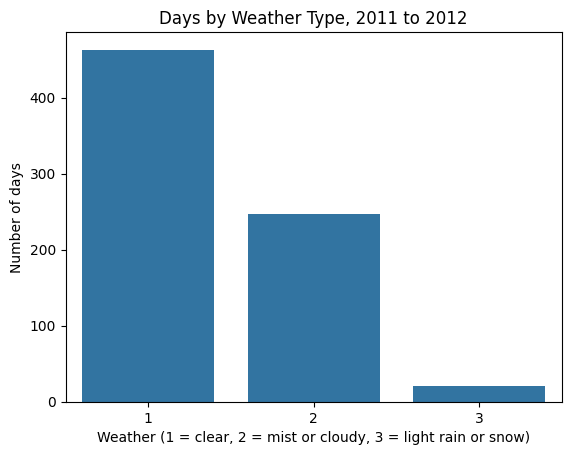

In [24]:
# RUN-TOGETHER  (worked example)
sns.countplot(data=bikes, x='weathersit')
plt.title('Days by Weather Type, 2011 to 2012')
plt.xlabel('Weather (1 = clear, 2 = mist or cloudy, 3 = light rain or snow)')
plt.ylabel('Number of days')
plt.show()

Two things to notice. First, the y-axis counts **days**, not riders, because each row of `bikes` is one day. Second, the data dictionary lists a category 4 (heavy rain, ice, or snow), but there is no bar for it: no day in these two years was coded 4. A category that never occurs is invisible in a countplot.

**(a) (3 points)** Make one appropriate, fully labeled, single-variable graph for **each** of the five columns below, one per cell. Among your graphs for the numerical columns, use **at least one histogram and at least one boxplot**.

`season`, `workingday`, `temp_C`, `hum`, `casual`

**Template for part (a).** Copy this into each cell below and replace every ALL-CAPS placeholder. `PLOT_FUNCTION` is `countplot`, `histplot`, or `boxplot`, whichever fits the column's family. (For a one-variable boxplot there is no y variable, so leave out the `plt.ylabel` line.)

```python
sns.PLOT_FUNCTION(data=bikes, x='COLUMN')
plt.title('A TITLE THAT SAYS WHAT IS SHOWN, AND FOR WHICH YEARS')
plt.xlabel('WHAT THE X-AXIS MEASURES, WITH UNITS OR CODE MEANINGS')
plt.ylabel('WHAT IS BEING COUNTED')
plt.show()
```

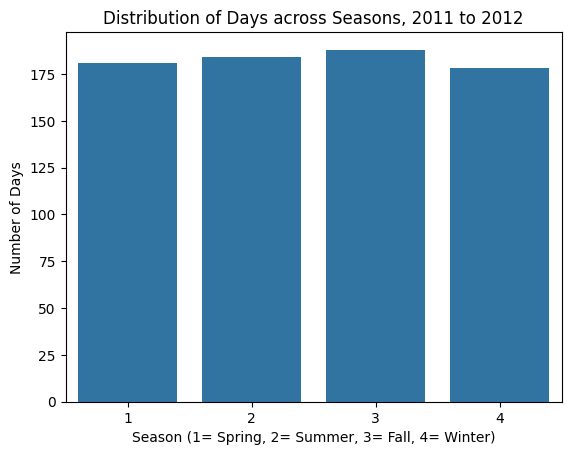

In [55]:
# Problem C1(a): season
sns.countplot(data=bikes, x='season')
plt.title('Distribution of Days across Seasons, 2011 to 2012')
plt.xlabel('Season (1= Spring, 2= Summer, 3= Fall, 4= Winter)')
plt.ylabel('Number of Days')
plt.show()

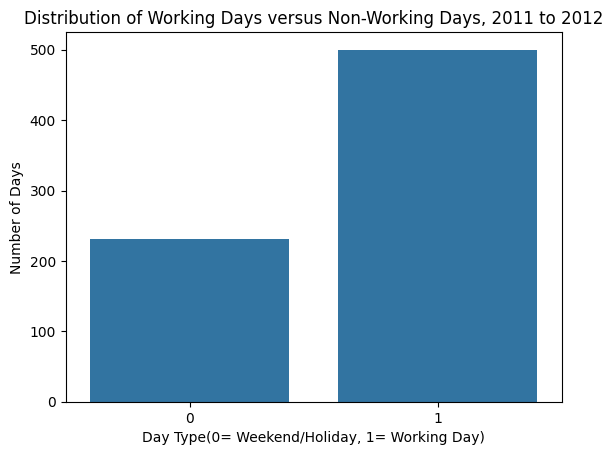

In [56]:
# Problem C1(a): workingday
sns.countplot(data=bikes, x='workingday')
plt.title('Distribution of Working Days versus Non-Working Days, 2011 to 2012')
plt.xlabel('Day Type(0= Weekend/Holiday, 1= Working Day)')
plt.ylabel('Number of Days')
plt.show()

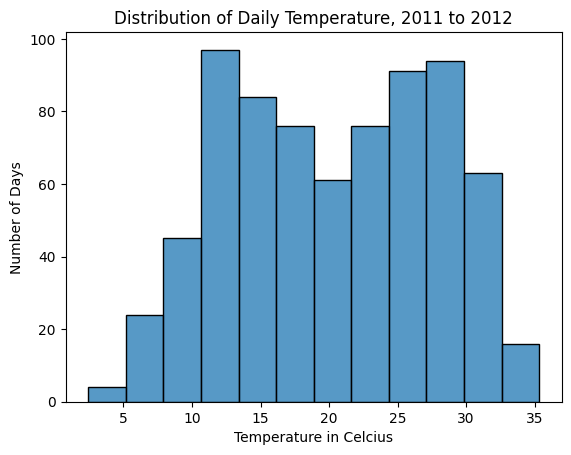

In [53]:
# Problem C1(a): temp_C
sns.histplot(data=bikes, x='temp_C')
plt.title('Distribution of Daily Temperature, 2011 to 2012')
plt.xlabel('Temperature in Celcius')
plt.ylabel('Number of Days')
plt.show()

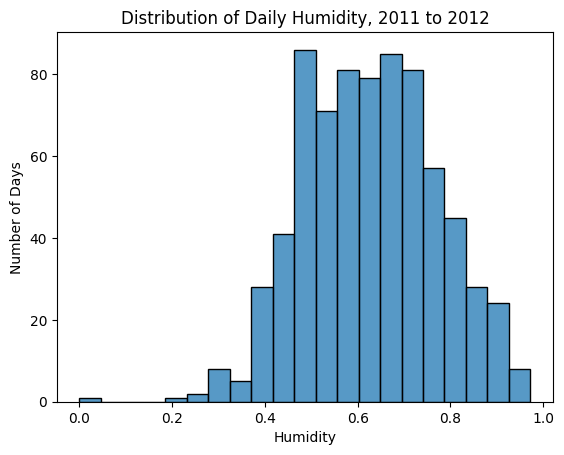

In [57]:
# Problem C1(a): hum
sns.histplot(data=bikes, x='hum')
plt.title('Distribution of Daily Humidity, 2011 to 2012')
plt.xlabel('Humidity')
plt.ylabel('Number of Days')
plt.show()

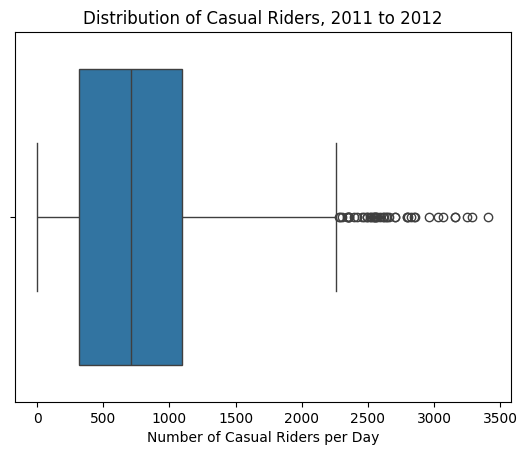

In [58]:
# Problem C1(a): casual
sns.boxplot(data=bikes, x='casual')
plt.title('Distribution of Casual Riders, 2011 to 2012')
plt.xlabel('Number of Casual Riders per Day')
plt.show()

**(b) (1 point)** Draw **one** of the relationship plots you planned in Problem A2(b) in rows 2 or 3. Fully label it.

*Hint:* because `season` and `workingday` are stored as numbers, seaborn may color them as a smooth gradient instead of as distinct groups. Adding `palette='tab10'` to your plotting call gives each group its own color. (Ask yourself why seaborn guessed wrong.)

**Template for part (b).**

```python
sns.scatterplot(data=bikes, x='X_COLUMN', y='Y_COLUMN', hue='GROUP_COLUMN', palette='tab10')
plt.title('Y AGAINST X, BY GROUP')
plt.xlabel('X, WITH UNITS')
plt.ylabel('Y, WITH UNITS')
plt.show()
```


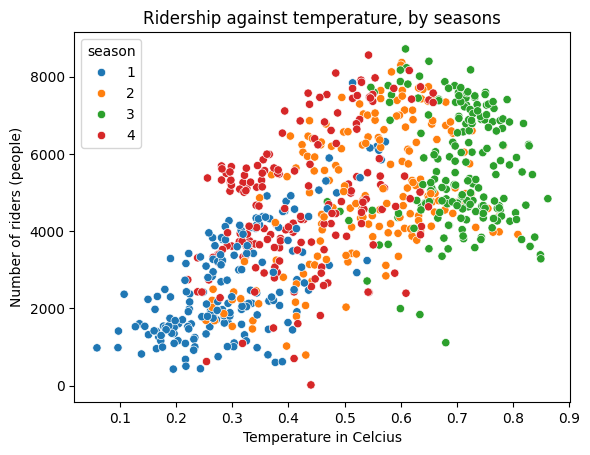

In [60]:
# Problem C1(b): your code here
#cnt , temp, seasons	numerical, categorical	scatterplot	seasons
sns.scatterplot(data=bikes, x='temp', y='cnt', hue='season', palette='tab10')
plt.title('Ridership against temperature, by seasons')
plt.xlabel('Temperature in Celcius')
plt.ylabel('Number of riders (people)')
plt.show()

**(c) (2 points)** Interpret.

- (i) Your `season` graph is nearly flat. What exactly is being counted? Does this graph tell you whether people ride more in some seasons than others? Which of your planned plots from A2(b) *would* answer that?
- (ii) One of your five columns contains a value that is physically implausible for a day of weather in Washington, D.C. Identify the column and the value, and say which graph type made it easier to spot and why. Then print the full row(s) with a boolean mask, e.g. `bikes[bikes['column'] < value]`, and report the date. What else in that row makes the value hard to believe?

**Your answer:**

(i) this counts the days in each season. This does not have anything to do with ridership. A2(b)#2 would answer that.

(ii) It is the humitity of zero that occurs in the hum column. This was easy to spot with the histogram. The day was March 10th and the fact that it was raining makes it hard to belive.

In [63]:
# Problem C1(c)(ii): print the suspicious row(s)
bikes[bikes['hum'] < 0.1]

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,temp_C
68,69,2011-03-10,1,0,3,0,4,1,3,0.389091,0.385668,0.0,0.261877,46,577,623,15.952731


### Problem C2. First contact with a new dataset (6 points)

You have never seen the `planets` dataset before. It records confirmed exoplanet discoveries: the detection `method`, the `number` of planets known in that system, the `orbital_period` in days, the planet `mass` in Jupiter masses, the `distance` from Earth in parsecs, and the discovery `year`.

(a) (2 points) Write code to report: the shape, how many missing values each column has, and how many distinct detection methods appear.

In [72]:
# Problem C2(a): your code here
print('Shape:', planets.shape)
print('Null for each column:', planets.isnull().sum())
print('Distinct Methods:', planets['method'].nunique())

Shape: (1035, 6)
Null for each column: method              0
number              0
orbital_period     43
mass              522
distance          227
year                0
dtype: int64
Distinct Methods: 10


(b) (2 points) Draw a histogram of `orbital_period` on a **linear** x-axis, then a second one on a **log** x-axis. Label both. (For the log version, `sns.histplot` accepts `log_scale=True`.)

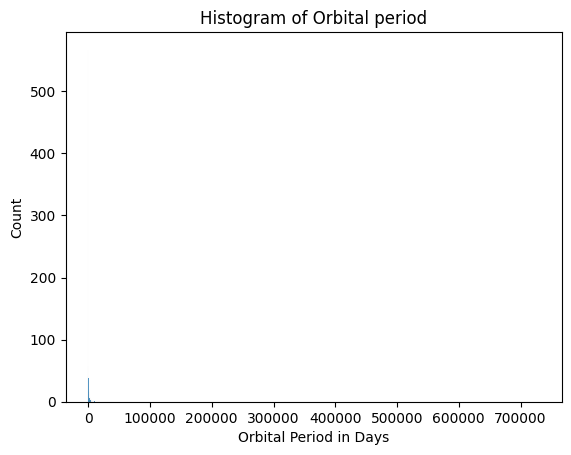

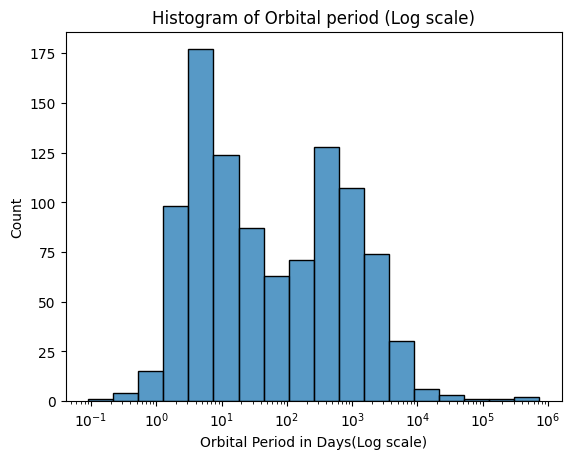

In [78]:
# Problem C2(b): your code here
sns.histplot(data=planets, x='orbital_period')
plt.title('Histogram of Orbital period')
plt.xlabel('Orbital Period in Days')
plt.ylabel('Count')
plt.show()
sns.histplot(data=planets, x='orbital_period', log_scale=True)
plt.title('Histogram of Orbital period (Log scale)')
plt.xlabel('Orbital Period in Days(Log scale)')
plt.ylabel('Count')
plt.show()

(c) (2 points) The linear histogram is nearly unreadable. Explain why, using the actual range of `orbital_period`, and say what the log version lets you see that the linear one hides. Then connect this to Module 5's Gapminder example: what did the log axis do there?

**Your answer:**

(c)  On the linear axis, the orbital period is all squashed to the left side. Each multipicative step has a similar gain on count and a log scale helps you to see this. With the gapminder example, the poorer countries were all squashed against the left edge and were just as hard to distingush. A log scale on the x-axis spreads them out and makes them readable.


---
## Part D. Application (12 points)
---

### Problem D1. Which method finds which planets? (6 points)

Different detection methods are sensitive to different kinds of planet. That is not a flaw in the data; it is physics, and it shows up as structure in the plot.

**A new tool: `.isin(...)`.** You know boolean masks that compare every row to *one* value, such as `planets['method'] == 'Transit'`. The method `.isin(...)` compares every row to a *list* of values and gives `True` when the row matches **any** of them. The result is an ordinary boolean mask, one `True` or `False` per row. Run the setup cell and read each printed result before moving on.


In [75]:
# RUN-TOGETHER  (setup for Problem D1)
# Step 1. The four most common detection methods, from a frequency table (Module 2).
top4 = planets['method'].value_counts().head(4).index
print('four most common methods:', list(top4))

# Step 2. A boolean mask: True if a planet's method is ANY of the four.
in_top4 = planets['method'].isin(top4)
print(in_top4.head())
print('planets in the top four methods:', in_top4.sum(), 'of', len(planets))

# Step 3. Keep only the rows where the mask is True.
planets4 = planets[in_top4]
print('planets4 shape:', planets4.shape)

four most common methods: ['Radial Velocity', 'Transit', 'Imaging', 'Microlensing']
0    True
1    True
2    True
3    True
4    True
Name: method, dtype: bool
planets in the top four methods: 1011 of 1035
planets4 shape: (1011, 6)


(a) (2 points) Using `planets4`, draw a scatterplot of `distance` against `orbital_period`, colored by `method`, with **both axes on a log scale**, fully labeled. For log axes on a scatterplot, use `plt.xscale('log')` and `plt.yscale('log')`, as in the Gapminder example.

In [80]:
# Problem D1(a): your code here
sns.scatterplot(data=planets4, x='distance', y='orbital period', hue='method', plt.xscale('log'), plt.yscale('log'))
plt.title('Scatterplot of distance against orbital_period, colored by method(Log scale)')
plt.ylabel('Orbital Period in Days')
plt.xlabel('Distance in parsecs')
plt.show()

SyntaxError: positional argument follows keyword argument (54860780.py, line 2)

(b) (2 points) Describe the structure. Do the methods overlap, or does each occupy its own region? Name one method and the corner of the plot it lives in.

(c) (2 points) Here is the important question. Suppose someone computes the average distance of all known exoplanets and reports it as "the typical planet distance in the galaxy." Using your figure, explain why that number would be badly wrong. Your answer should use the word *sample* and should connect to the Module 4 idea that a single number computed over a mixed population can mislead.

**Your answer:**

(b)

(c)


### Problem D2. COMMUNICATE: one figure and a Professional Summary (6 points)

Everything so far has been EXPLORE. This problem is the last stage of the loop.

```
ASK  ->  GET  ->  EXPLORE  ->  MODEL  -> [ COMMUNICATE ]
```

**Your task.** Choose **one** question you can answer with `planets`, `bikes`, or `titanic` (or `penguins`, as long as your question is not one we explored in a Module 5 activity). Produce the **single best figure** that answers it, and write a Professional Summary reporting the finding.

Some questions worth asking, though you are encouraged to invent your own:

- Has the typical mass of newly discovered planets changed over time?
- Which detection method has dominated in recent years?
- On days off, does temperature seem to matter more for casual riders than for registered members?
- Within each passenger class, did Titanic survivors tend to pay higher fares than those who died?

**(a) (1 point) State your question** in one sentence, precise enough that data could settle it.

**Your question:**


**(b) (2 points) The figure.** One figure with a title, labeled axes with units, and a legend if you use `hue`.

In [ ]:
# Problem D2(b): your figure here


**(c) (3 points) The Professional Summary.**

Write **3 to 5 sentences** reporting your finding as you would to a colleague who has not seen your code. A Professional Summary states what was measured, what was found (with specific numbers), and what the limits of the finding are. It does not narrate your process, and it never says "as you can see in the figure."

Here is the example to aim for based on the Worked Example in Problem C1:

> *This bar chart shows how many of the 731 days in Capital Bikeshare's 2011–2012 records fell into each weather category. Clear weather was the most common by a wide margin, with 463 days (about 63%). Misty or cloudy conditions followed with 247 days (about 34%), and light rain or snow occurred on only 21 days (about 3%). No day was coded as category 4 (heavy rain, ice, or snow), so that category has no bar. Because the counts are so uneven, any comparison of ridership across weather types should account for the small number of bad-weather days.*

Notice the shape: **what was measured, what was found with numbers, where it breaks down.** Your last sentence should name a genuine limitation, and "more data would help" is not one.

**Your Professional Summary:**

